# Machine Learning for Delta Hedging

This tutorial demonstrates **ML-based delta hedging** in a front-office quant setting: we train a neural network to approximate the Black–Scholes delta, then backtest hedging performance against the classical BSM strategy on simulated paths.

## What You'll Learn

| Section | Topics |
|---------|--------|
| **Mathematical framework** | Optimal delta hedging (continuous and discrete), hedging error, transaction costs |
| **Simulation** | GBM paths, BSM price and delta at rebalancing times |
| **Training** | Supervised learning of delta (MSE loss), TFDataset, MLP |
| **Backtest** | BSM vs ML hedge on same paths; P&L and cost comparison |
| **Evaluation** | Metrics (mean/std P&L, VaR, CVaR, cost), visualisations |

## Prerequisites

From the project root: `pip install -r requirements.txt`. Run the **Setup and imports** cell first.

In [ ]:
# Setup and imports — run this cell first
import sys
from pathlib import Path

def _find_project_root():
    path = Path.cwd()
    for _ in range(6):
        if (path / "src" / "m_learning").exists():
            return path
        if path.parent == path:
            break
        path = path.parent
    return Path.cwd().parents[2] if Path.cwd().parts[-3:] == ("docs", "tutorials", "m_learning") else path

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

np.random.seed(42)
tf.random.set_seed(42)
print(f"Project root: {project_root}\nTensorFlow: {tf.__version__}")

Project root: /Users/joesstevens/PycharmProjects/QuantStrata
TensorFlow: 2.20.0


---
## Mathematical framework

### 1. Optimal delta hedging: problem formulation

**Setting.** Under the risk-neutral measure **Q**, the underlying follows
$$dS_t = r S_t \\, dt + \\sigma S_t \\, dW_t.$$
A European option has value \\(V(t,S_t)\\) satisfying the Black–Scholes PDE:
$$\\frac{\\partial V}{\\partial t} + r S \\frac{\\partial V}{\\partial S} + \\frac{1}{2} \\sigma^2 S^2 \\frac{\\partial^2 V}{\\partial S^2} - r V = 0.$$
The **delta** is \\(\\Delta_t = \\frac{\\partial V}{\\partial S}(t, S_t)\\). In continuous time, holding \\(\\Delta_t\\) units of the underlying at each instant and financing with the risk-free account yields a self-financing replicating portfolio; the hedging error is zero.

**Discrete rebalancing.** We rebalance at dates \\(0 = t_0 < t_1 < \\cdots < t_N = T\\). The hedge is held constant on \\((t_k, t_{k+1})\\). The **cumulative discounted P&L** of the hedged short option position is
$$\\Pi_N = -e^{-rT} V(T,S_T) + V(0,S_0) + \\sum_{k=0}^{N-1} \\Delta_k \\left( e^{-r t_{k+1}} S_{t_{k+1}} - e^{-r t_k} S_{t_k} \\right) - \\sum_{k=1}^{N-1} e^{-r t_k} C_k,$$
where \\(\\Delta_k\\) is the hedge ratio chosen at \\(t_k\\) and \\(C_k \\geq 0\\) is the transaction cost at \\(t_k\\).

**Hedging error.** The terminal **hedging error** is \\(\\varepsilon = \\Pi_N\\). With no costs and \\(\\Delta_k = \\Delta(t_k, S_{t_k})\\) (BSM delta), \\(\\varepsilon\\) is driven by **discretisation** (gamma/theta between dates): \\(\\mathbb{E}[\\varepsilon] \\approx 0\\) but \\(\\mathrm{Var}(\\varepsilon) > 0\\).

**Optimality.** The optimal discrete hedge can minimise e.g. \\(\\mathrm{Var}(\\varepsilon)\\) or cost-adjusted risk. Under GBM with no cost, BSM delta at each \\(t_k\\) is a standard and nearly optimal choice. With transaction costs, the true optimal trades off tracking error and cost; we take **BSM delta as the benchmark** and use ML to **approximate** it, then measure realised P&L and cost.

### 2. How the ML model addresses the problem

**Supervised formulation.** We do *not* minimise \\(\\mathrm{Var}(\\varepsilon)\\) directly. We:
- **Target:** BSM delta \\(\\Delta^*(t,S) = \\frac{\\partial V_{\\mathrm{BS}}}{\\partial S}(t,S; K, r, \\sigma, \\mathrm{type})\\) at each rebalancing state.
- **Model:** MLP \\(\\widehat{\\Delta}_\\theta(x)\\) with \\(x = (S/K, T-t, \\sigma, r, \\mathrm{type})\\).
- **Training:** Minimise \\(\\mathcal{L}(\\theta) = \\mathbb{E}_{(x,\\Delta^*)}[(\\widehat{\\Delta}_\\theta(x) - \\Delta^*)^2]\\) (MSE).

**Interpretation.** The BSM delta is the continuous-time optimal hedge; we approximate it with a neural network. We then **evaluate** by backtesting and comparing P&L and cost of the ML-hedged portfolio vs the BSM-hedged portfolio.

**Extensions (not in this notebook):** Direct risk minimisation (\\(\\min_\\theta \\mathrm{Var}(\\varepsilon)\\)), RL (hedge ratio as action), or learning the minimum-variance discrete delta from paths.

### 3. From equations to code

| Concept | Maths | Code |
|---------|--------|------|
| Spot dynamics | \\(S_{t_{k+1}} = S_{t_k} \\exp((r - \\sigma^2/2)\\Delta t + \\sigma\\sqrt{\\Delta t}\\,Z_k)\\) | `generate_gbm_path`, `simulate_hedging_path` |
| Option value / delta | \\(V = V_{\\mathrm{BS}}(t,S;...)\\), \\(\\Delta = \\partial V/\\partial S\\) | `vanilla_price`, `vanilla_greeks` in BSM module |
| Rebalance / cost | \\(C_k = c \\cdot |\\Delta_k - \\Delta_{k-1}| \\cdot S_{t_k}\\) | `run_single_path_backtest` |
| Training target | \\(\\Delta^* = \\Delta_{\\mathrm{BS}}\\) | `build_delta_hedging_dataset` → target = BSM delta |
| Loss | \\(\\mathbb{E}[(\\widehat{\\Delta}_\\theta(x) - \\Delta^*)^2]\\) | MSE in Keras |

---
## 1. Simulation

We generate GBM paths and, at each rebalancing time, compute BSM option value and delta. This gives the benchmark hedge and the training targets.

In [ ]:
from src.m_learning.data.delta_hedging import (
    simulate_hedging_path,
    simulate_hedging_paths,
    HedgingPath,
)

S0, K, T = 100.0, 100.0, 1.0
r, sigma = 0.05, 0.2
option_type = 1   # 1 = call, -1 = put
n_steps = 252     # daily rebalancing

path = simulate_hedging_path(S0, K, T, r, sigma, option_type, n_steps, seed=42)
print(f"Path: {path.n_steps + 1} times, spot range [{path.spot.min():.2f}, {path.spot.max():.2f}]")
print(f"Delta at t=0: {path.delta[0]:.4f}, at expiry: {path.delta[-1]:.4f}")

Path: 253 times, spot range [84.47, 107.81]
Delta at t=0: 0.6368, at expiry: 0.0000


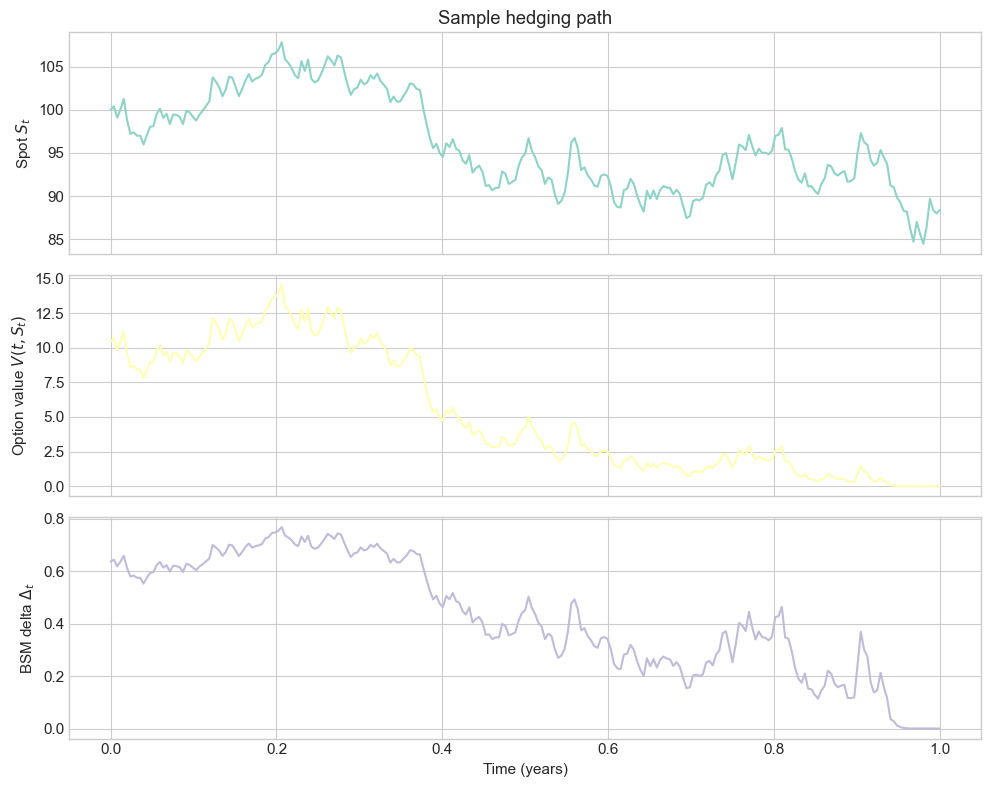

In [ ]:
# Sample path: spot, option value, BSM delta
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
t = path.times
axes[0].plot(t, path.spot, color="C0")
axes[0].set_ylabel("Spot $S_t$")
axes[0].set_title("Sample hedging path")
axes[1].plot(t, path.option_value, color="C1")
axes[1].set_ylabel("Option value $V(t,S_t)$")
axes[2].plot(t, path.delta, color="C2")
axes[2].set_ylabel("BSM delta $\\Delta_t$")
axes[2].set_xlabel("Time (years)")
plt.tight_layout()
plt.show()

---
## 2. Training data

Build dataset: features = (moneyness S/K, time to expiry, vol, rate, option type), target = BSM delta. Split train/val/test.

In [ ]:
from src.m_learning.data import TFDataset
from src.m_learning.data.delta_hedging import build_delta_hedging_dataset, DELTA_HEDGE_FEATURE_NAMES

n_paths_train = 300
features, targets = build_delta_hedging_dataset(
    n_paths=n_paths_train,
    S0=S0, K=K, T=T, r=r, sigma=sigma,
    option_type=option_type,
    n_steps=n_steps,
    seed=42,
)
dataset = TFDataset.from_arrays(
    features, targets,
    feature_names=DELTA_HEDGE_FEATURE_NAMES,
    target_names=["delta"],
)
dataset.normalize_features(method="zscore")
train_ds, val_ds, test_ds = dataset.split(train=0.7, val=0.15, test=0.15, seed=42)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print("Feature names:", train_ds.feature_names)

Train: 53130, Val: 11385, Test: 11385
Feature names: ['moneyness', 'time_to_expiry', 'vol', 'rate', 'option_type']


---
## 3. Model: MLP for delta

Train an MLP to predict BSM delta from the normalised features. Loss = MSE (\\(\\mathcal{L}(\\theta)\\) in the theory).

In [ ]:
n_feat = train_ds.features.shape[1]
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_feat,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
batch_size = 256
train_tf = train_ds.to_tf_dataset(batch_size=batch_size, shuffle=True)
val_tf = val_ds.to_tf_dataset(batch_size=batch_size, shuffle=False)
history = model.fit(train_tf, validation_data=val_tf, epochs=150, verbose=1)

Epoch 1/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0258 - mae: 0.0672 - val_loss: 9.7129e-04 - val_mae: 0.0132
Epoch 2/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.8563e-04 - mae: 0.0103 - val_loss: 5.2717e-04 - val_mae: 0.0098
Epoch 3/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2361e-04 - mae: 0.0074 - val_loss: 3.2019e-04 - val_mae: 0.0071
Epoch 4/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1901e-04 - mae: 0.0057 - val_loss: 2.4869e-04 - val_mae: 0.0053
Epoch 5/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - loss: 1.8273e-04 - mae: 0.0054 - val_loss: 2.1321e-04 - val_mae: 0.0056
Epoch 6/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 1.5632e-04 - mae: 0.0049 - val_loss: 1.9799e-04 - val_mae: 0.0044
Epoch 7/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - loss: 1.3813e-04 - mae: 0.0047 - val_loss: 1.7473e-04 - val_mae: 0.0044
Epoch 8/150
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - loss: 1.2806e-04 - mae: 0.0048 - val_loss: 1.6031e-0

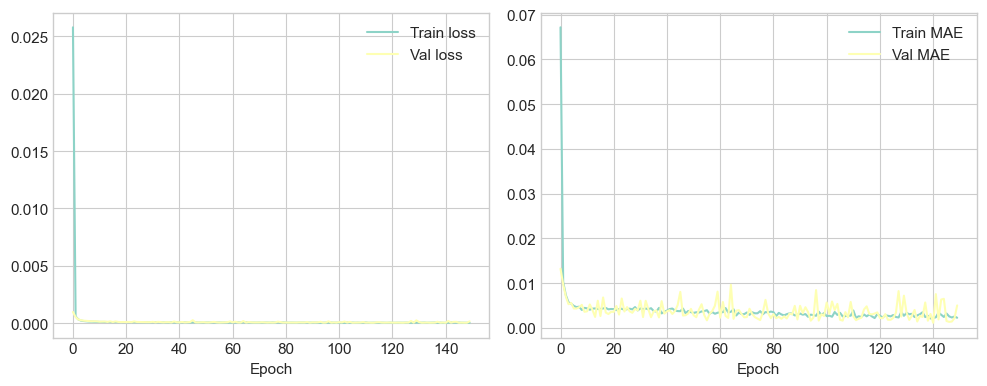

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.legend()
plt.xlabel("Epoch")
plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.legend()
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()

---
## 4. Backtest

Simulate **test** paths (out-of-sample), run BSM and ML hedging on the same paths, and record terminal P&L and transaction costs. We use a small cost rate so that cost is visible but not dominant.

In [ ]:
from src.m_learning.evaluation.delta_hedging_backtest import (
    run_delta_hedging_backtest,
    backtest_summary_stats,
)
from src.m_learning.data.delta_hedging import path_to_feature_target_arrays

n_paths_test = 200
test_paths = simulate_hedging_paths(
    n_paths=n_paths_test, S0=S0, K=K, T=T, r=r, sigma=sigma,
    option_type=option_type, n_steps=n_steps, seed=123,
)
cost_rate = 0.001  # proportional cost per unit notional traded

def ml_delta_fn(features_raw):
    # Normalise with same stats as training
    f = train_ds.feature_stats.normalize(features_raw.astype(np.float32))
    pred = model.predict(f, verbose=0)
    return np.squeeze(pred)

result = run_delta_hedging_backtest(
    test_paths, K=K, T=T, r=r, sigma=sigma, option_type=option_type,
    cost_rate=cost_rate, ml_delta_fn=ml_delta_fn,
)
stats = backtest_summary_stats(result, var_percentile=5.0)
print("Backtest summary:")
for k, v in stats.items():
    print(f"  {k}: {v:.6f}" if isinstance(v, float) else f"  {k}: {v}")

Backtest summary:
  mean_pnl_bsm: 2.375179
  std_pnl_bsm: 1.309107
  var_bsm: 0.319031
  mean_cost_bsm: 0.489007
  cvar_bsm: 0.011846
  mean_pnl_ml: 2.361832
  std_pnl_ml: 1.252592
  var_ml: 0.416836
  mean_cost_ml: 0.486446
  cvar_ml: 0.131120


---
## 5. Evaluation and visualisation

**Metrics:** Mean and std of terminal P&L, VaR (5%), CVaR (5%), mean transaction cost for BSM vs ML.

**Plots:** Terminal P&L distribution (BSM vs ML); delta accuracy (ML vs BSM scatter); summary table.

In [ ]:
summary_df = pd.DataFrame({
    "Strategy": ["BSM", "ML"],
    "Mean P&L": [stats["mean_pnl_bsm"], stats["mean_pnl_ml"]],
    "Std P&L": [stats["std_pnl_bsm"], stats["std_pnl_ml"]],
    "VaR (5%)": [stats["var_bsm"], stats["var_ml"]],
    "CVaR (5%)": [stats["cvar_bsm"], stats["cvar_ml"]],
    "Mean cost": [stats["mean_cost_bsm"], stats["mean_cost_ml"]],
})
print(summary_df.to_string(index=False))

Strategy  Mean P&L  Std P&L  VaR (5%)  CVaR (5%)  Mean cost
     BSM  2.375179 1.309107  0.319031   0.011846   0.489007
      ML  2.361832 1.252592  0.416836   0.131120   0.486446


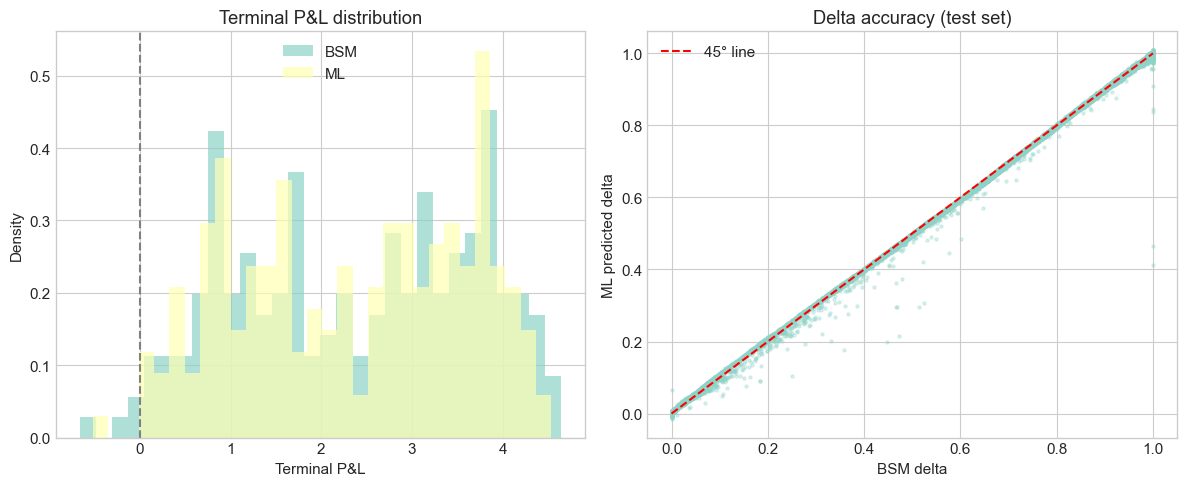

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(result.terminal_pnl_bsm, bins=30, alpha=0.7, label="BSM", color="C0", density=True)
axes[0].hist(result.terminal_pnl_ml, bins=30, alpha=0.7, label="ML", color="C1", density=True)
axes[0].set_xlabel("Terminal P&L")
axes[0].set_ylabel("Density")
axes[0].set_title("Terminal P&L distribution")
axes[0].legend()
axes[0].axvline(0, color="gray", linestyle="--")

# Delta accuracy: ML vs BSM on test set
pred_test = model.predict(test_ds.features, verbose=0)
axes[1].scatter(test_ds.targets.flatten(), np.squeeze(pred_test), alpha=0.3, s=5)
mn, mx = test_ds.targets.min(), test_ds.targets.max()
axes[1].plot([mn, mx], [mn, mx], "r--", label="45° line")
axes[1].set_xlabel("BSM delta")
axes[1].set_ylabel("ML predicted delta")
axes[1].set_title("Delta accuracy (test set)")
axes[1].legend()
plt.tight_layout()
plt.show()

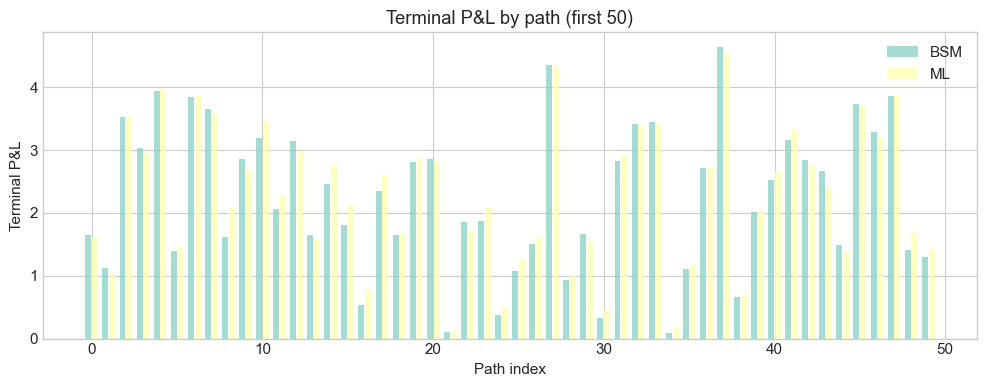

In [ ]:
# P&L by path index (first 50 paths)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(min(50, result.n_paths))
ax.bar(x - 0.2, result.terminal_pnl_bsm[:len(x)], width=0.35, label="BSM", color="C0", alpha=0.8)
ax.bar(x + 0.2, result.terminal_pnl_ml[:len(x)], width=0.35, label="ML", color="C1", alpha=0.8)
ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)
ax.set_xlabel("Path index")
ax.set_ylabel("Terminal P&L")
ax.set_title("Terminal P&L by path (first 50)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Conclusion

We approximated the **Black–Scholes delta** with an MLP trained by supervised learning (MSE) and compared **BSM delta hedging** vs **ML delta hedging** on out-of-sample paths. The mathematical framework showed that BSM delta is the continuous-time replicating hedge and that in discrete time the residual risk is discretisation (gamma/theta); we used BSM delta as the training target and then evaluated realised P&L and transaction costs.

**Extensions:** Direct variance minimisation of hedging error, reinforcement learning (hedge ratio as action), cost-aware policies (e.g. rebalancing bands), or different dynamics (e.g. jump diffusion).